In [65]:
!ls

itch.ipynb
make_modeling_data.ipynb
mod_med_3f_days.ipynb
mod_med_3f_months.ipynb
mod_med_3f_weeks.ipynb
model.md
model_01.ipynb
model_02-gabi.ipynb
model_02.ipynb
model_02_almost.ipynb
model_02_raw.ipynb
model_03.ipynb
model_03_almost.ipynb
model_04.ipynb
model_04_learning_curve.ipynb
model_04_raw.ipynb
model_05_ridge_oldest.ipynb
model_05a_ridge_14.ipynb
model_05a_ridge_15.ipynb
model_05a_ridge_16.ipynb
model_05a_ridge_17.ipynb
model_06_lasso_b.ipynb
model_07_ransac.ipynb
model_08_random_forest.ipynb
model_median_01.ipynb
model_median_01_log.ipynb
model_median_02.ipynb
model_median_02_fixit.ipynb
model_median_03.ipynb
model_rolling_median_01.ipynb
scratch.ipynb
untitled.txt


In [1]:
import numpy as np


In [2]:
v1 = np.arange(1, 11); v1

array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10])

In [5]:
thing = v1.reshape(-1, 1)

In [6]:
thing

array([[ 1],
       [ 2],
       [ 3],
       [ 4],
       [ 5],
       [ 6],
       [ 7],
       [ 8],
       [ 9],
       [10]])

In [7]:
vc1 = thing

In [8]:
vc2 = 100 * thing; vc2

array([[ 100],
       [ 200],
       [ 300],
       [ 400],
       [ 500],
       [ 600],
       [ 700],
       [ 800],
       [ 900],
       [1000]])

In [14]:
thing = np.vstack([vc1, vc2]); thing

array([[   1],
       [   2],
       [   3],
       [   4],
       [   5],
       [   6],
       [   7],
       [   8],
       [   9],
       [  10],
       [ 100],
       [ 200],
       [ 300],
       [ 400],
       [ 500],
       [ 600],
       [ 700],
       [ 800],
       [ 900],
       [1000]])

In [15]:
rv1 = np.arange(1, 6); rv1

array([1, 2, 3, 4, 5])

In [16]:
rv2 = 100 * rv1; rv2

array([100, 200, 300, 400, 500])

In [19]:
thing = np.vstack([rv1, rv2]); thing

array([[  1,   2,   3,   4,   5],
       [100, 200, 300, 400, 500]])

In [52]:
x = np.linspace(1.0, 1000, 10000)

In [22]:
x

array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
       18, 19, 20, 21, 22, 23, 24])

In [54]:
y = 1/x

In [24]:
import matplotlib.pyplot as plt


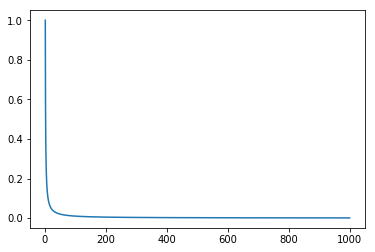

In [48]:
plt.plot(x, y)

In [26]:
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import r2_score, mean_squared_error, make_scorer
from sklearn.model_selection import train_test_split, cross_val_score, KFold, GridSearchCV
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.pipeline import Pipeline

In [30]:
# Setup the pipeline steps
steps = [('scaler', StandardScaler()),
         ('poly', PolynomialFeatures()),
         ('LR', LinearRegression())]

# Create the pipeline: pipeline 
pipeline = Pipeline(steps)

In [55]:
# want to plot both R2 and RMSE
def RMSE(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

# Create the hyperparameter grid, just poly degree
poly_space = np.arange(1, 21)
param_grid = {'poly__degree': poly_space}

# Create train and test sets
X_train, X_test, y_train, y_test = train_test_split(np.log(x.reshape(-1,1)), y.reshape(-1,1), test_size=0.30, random_state=21)

# build the scoring map
scoring = {'Rsquared': 'r2',
           'RMSE': make_scorer(RMSE, greater_is_better=False) }

# Create the GridSearchCV object: gs_cv
gs_cv = GridSearchCV(pipeline, param_grid, cv=3, scoring=scoring, 
                     return_train_score=True, refit='Rsquared')

# Fit to the training set
gs_cv.fit(X_train, y_train)

# Compute and print the metrics
theR2 = gs_cv.score(X_test, y_test)
print("Best parameters: {}".format(gs_cv.best_params_))
print("test R squared: {}".format(theR2))

# uncomment to see results ds
# gs_cv.cv_results_

Best parameters: {'poly__degree': 14}
test R squared: 1.0


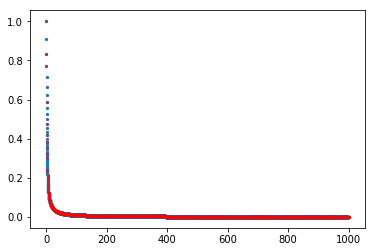

In [64]:
plt.scatter(x, y, s=5)
plt.scatter(np.exp(X_test), gs_cv.predict(X_test), s=5, alpha = 0.4, color='red')

In [57]:
gs_cv.cv_results_

{'mean_fit_time': array([0.00167123, 0.00133737, 0.00133427, 0.00166178, 0.00133491,
        0.00199223, 0.00200518, 0.00200566, 0.00167108, 0.00167187,
        0.00199421, 0.00200502, 0.00334255, 0.00300988, 0.00334231,
        0.00401004, 0.00334183, 0.00367546, 0.00367673, 0.00402228]),
 'std_fit_time': array([4.72662947e-04, 4.72664070e-04, 4.69291362e-04, 9.57709438e-04,
        4.75601782e-04, 8.03736318e-04, 8.18968116e-04, 2.24783192e-07,
        4.72888131e-04, 4.71595177e-04, 1.85153002e-05, 2.97360213e-07,
        4.73281051e-04, 2.68566533e-06, 4.73449848e-04, 8.50796520e-04,
        4.71092281e-04, 9.45944474e-04, 9.43360312e-04, 8.18562369e-04]),
 'mean_score_time': array([0.00100271, 0.00100271, 0.00100303, 0.00065343, 0.00098864,
        0.00133713, 0.00100239, 0.00100295, 0.00100319, 0.00168212,
        0.0013361 , 0.00232712, 0.0020055 , 0.0023373 , 0.00133602,
        0.00167243, 0.00200478, 0.00201662, 0.00267275, 0.00267466]),
 'std_score_time': array([1.12391596e-

In [58]:
np.sqrt(0.85)

0.9219544457292888